# Two steps neural network 
Time and diffusive parameters

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os
from itertools import product

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Data preparation

In [2]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations_time.txt")
#file_path_diff = os.path.join("..", "..", "Diffusion\DATA", "diffusion.txt")

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)


In [3]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, t_HF_test) = import_data(file_path_HF)
t_HF_test=t_HF_test.T

In [4]:
########################     NORMALIZATION  #########################
# Input

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

t_max = np.max(t_HF_test)
t_min = np.min(t_HF_test)

t_HF_test = (t_HF_test - t_min) / (
    t_max - t_min
)



In [5]:
#########################     TRAIN SET      ##########################
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoHF = 4000  # number of epochs for second NN: NN_HF

Nlf = 150

In [6]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))
n_HF = 70

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
t_HF = t_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))

#reaction_HF = np.column_stack((reaction_HF, t_HF))
U_HF_test = U_HF_test[:, :, 44,44]

reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))


reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]




# TRANSFORMATION
U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##

In [7]:
print(U_HF.shape)
print(permutation[:,0].shape)
print(reaction_HF.shape)

(3500,)
(3500,)
(3500, 4)


In [8]:
U_LF_list = []
U_HF_list = []

diffusion=[5]

r2_HF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores LF MSE

********************  # Nb. nodes = 801  ********************
********************  # Diff: = 5  ********************
LF NN done
1252/1252 [==============================] - 3s 2ms/step

LF Model:
Test MSE: 0.006438537205641593
R^2: 0.9365551806292365
1252/1252 [==============================] - 2s 1ms/step
Elapsed time:  497.57533109991346

HF Model:
Test MSE: 0.010479625546696217
R^2: 0.9069663659316378
26/26 [==============================] - 0s 2ms/step


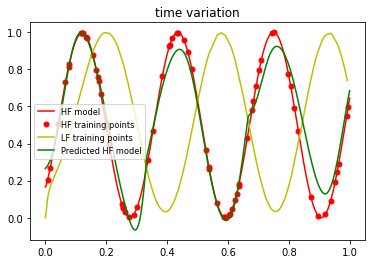

2/2 [==============================] - 0s 0s/step


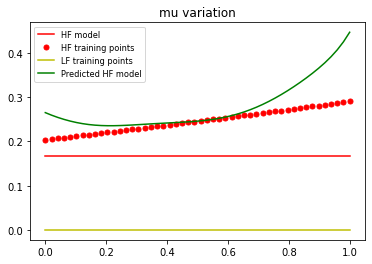

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:218: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:220: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:222: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:224: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 81  ********************
********************  # Diff: = 5  ********************
LF NN done
127/127 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10203243016004204
R^2: 0.10517949192967213
1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  515.3398416999262

HF Model:
Test MSE: 0.11191890051672827
R^2: 0.0064318625116076555
26/26 [==============================] - 0s 2ms/step


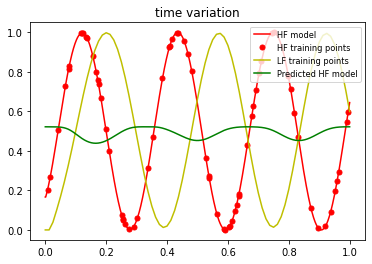

2/2 [==============================] - 0s 4ms/step


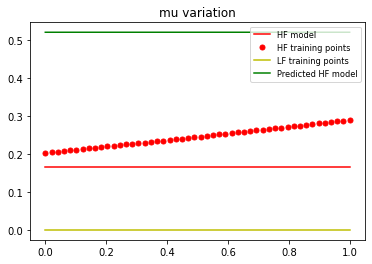

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:218: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:220: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:222: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:224: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 41  ********************
********************  # Diff: = 5  ********************
LF NN done
65/65 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11714979233111074
R^2: -0.00027236270379904504
1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  533.1111889999593

HF Model:
Test MSE: 0.11269199689760574
R^2: -0.00043135654881032437
26/26 [==============================] - 0s 2ms/step


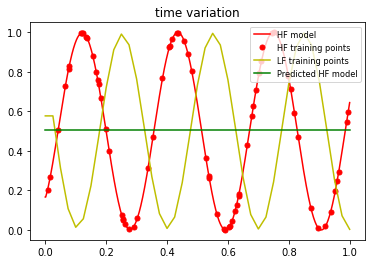

2/2 [==============================] - 0s 3ms/step


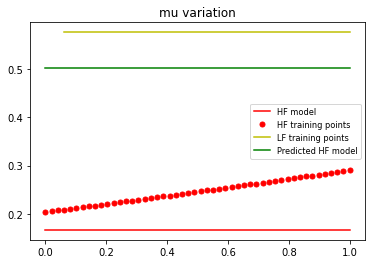

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:218: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:220: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:222: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:224: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 9  ********************
********************  # Diff: = 5  ********************
LF NN done
15/15 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.012731536321690835
R^2: 0.891217285662137
1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  541.8872940000147

HF Model:
Test MSE: 0.11265719941078738
R^2: -0.0001224393417276204
26/26 [==============================] - 0s 2ms/step


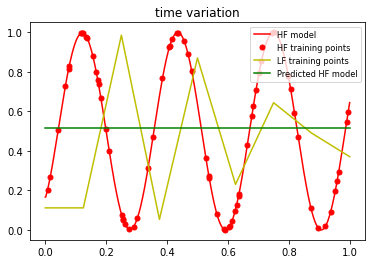

2/2 [==============================] - 0s 0s/step


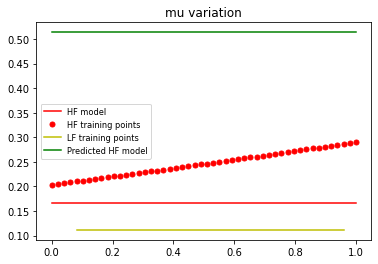

   Discretization       R2
0             0.0  0.90697
1             5.0  0.00643
2            10.0 -0.00043
3            50.0 -0.00012
   Discretization      MSE
0             0.0  0.01048
1             5.0  0.11192
2            10.0  0.11269
3            50.0  0.11266


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:218: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:220: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:222: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_13980\3469071717.py:224: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

In [9]:
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []


#############à
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat")
        #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, t_LF_test) = import_data(file_name)
        t_LF_test=t_LF_test.T
#file_path_LF = "..\..\Diffusion\DATA\reaction_diffusion_LF_46_d75.mat"
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        #print(reaction_LF.shape)
        
        t_max = np.max(t_LF_test)
        t_min = np.min(t_LF_test)
        t_LF_test = (t_LF_test - t_min) / (
            t_max - t_min
        )
        print(
        f"********************  # Nb. nodes = {t_LF_test.shape[0]}  ********************"
        )
        
        ######### DATASET
        L=np.minimum(Nlf,t_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(t_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:L]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        t_LF = t_LF_test[permutation2][0:L]
        
        #reaction_LF = np.column_stack((reaction_LF, t_LF))
        grid1, grid2 = np.meshgrid(reaction_LF, t_LF)
        reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))   # <--------
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), t_LF_test.flatten())))
        
        U_LF_test = U_LF_test[
        :,
        :,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        
        #
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(3*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
        reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(3*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]
        #
        
        # TRANSFORMATION
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)

        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
        #U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
        #print(U_LF_test)
        p1, p2 = np.meshgrid(permutation1[0:L], permutation2[0:L])
        permutation = np.column_stack((p1.ravel(), p2.ravel()))
        U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
        #U_train_LF = U_LF_test[permutation1[0:L],permutation2[0:L]]
        #print(U_train_LF)
        #print(permutation)
        ##
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]
        #######      

        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 
        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        #        histLF = modelLF.fit(Young_LF_norm[:,0], U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        ### SECOND NN#####################
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )

        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        ### plot
        plt.figure()
        mask1_test=np.where(reaction_test_in[:,0]==np.min(reaction_test_in[:,0]))
        mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
        mask1_LF=np.where(reaction_LF[:,0]==np.min(reaction_LF[:,0]))
        order=np.argsort(reaction_LF[mask1_LF,1])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask1_test, 1].T,
        finalModel.predict(reaction_test_in[mask1_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})  
        plt.title("time variation")
        plt.show()

        plt.figure()
        mask2_test=np.where(reaction_test_in[:,1]==np.min(reaction_test_in[:,1]))
        mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
        mask2_LF=np.where(reaction_LF[:,1]==np.min(reaction_LF[:,1]))
        order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]][:,0], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask2_test, 0].T,
        finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )
        #print(U_HF_test.shape)
        #print(U_HF_test[mask2_test].shape)
        #print(U_HF[mask2])
        plt.legend(prop={"size": 8.3})
        plt.title("mu variation")
        plt.show()

        new = {'Discretization': Discretizations[m], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))


In [10]:
print(U_HF[mask2])

[0.22550997 0.22895553 0.24117255 0.27734008 0.25542353 0.25004436
 0.20527639 0.23765735 0.22038017 0.26630372 0.25903244 0.28478064
 0.26265927 0.23416172 0.23242132 0.26447931 0.25362588 0.27549017
 0.21868063 0.20693295 0.26084363 0.23068591 0.23941253 0.25722573
 0.26996553 0.24470705 0.21193541 0.22379487 0.28291444 0.21361372
 0.26813248 0.27364441 0.22208492 0.20362535 0.21529738 0.28852496
 0.27919412 0.24826056 0.290403   0.21698636 0.28105225 0.22723021
 0.25183281 0.27180286 0.24293741 0.23590707 0.20859499 0.24648144
 0.21026249 0.28665083]


2/2 [==============================] - 0s 6ms/step


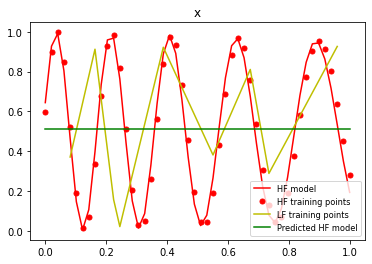

In [11]:
plt.figure()
mask2_test=np.where(reaction_test_in[:,1]==np.max(reaction_test_in[:,1]))
mask2=np.where(reaction_final[:,1]==np.max(reaction_final[:,1]))    
mask2_LF=np.where(reaction_LF[:,1]==np.max(reaction_LF[:,1]))
order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
plt.plot(
reaction_test_in[mask2_test, 0].T,
finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
"g-",
markersize=5,
label="Predicted HF model",
)

plt.legend(prop={"size": 8.3})
plt.title("x")
plt.show()

## Save the output

In [13]:
os.makedirs("MF_LF_150_5000_HF_75_4000_2NNt_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)